# Polynomial Regression

Polynomial Regression is a form of linear regression where the relationship between the independent variable (x) and the dependent variable (y) is modelled as an 
n
t
h
n 
th
  degree polynomial. It is useful when the data exhibits a non-linear relationship allowing the model to fit a curve to the data.

Need for Polynomial Regression : 

Non-linear Relationships ,
Better Fit for Curved Data ,
Flexibility and Complexity .


Polynomial Regression is a type of Linear Regression where the relationship between the independent variable 
𝑥
x and dependent variable 
𝑦
y is modeled as an n-th degree polynomial.

eqxn : polynomial

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures 

Loading dataset :

In [15]:
df = pd.read_csv("salarylevelwise.csv")
df.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manger,5,110000


Checking the behaviour of data :


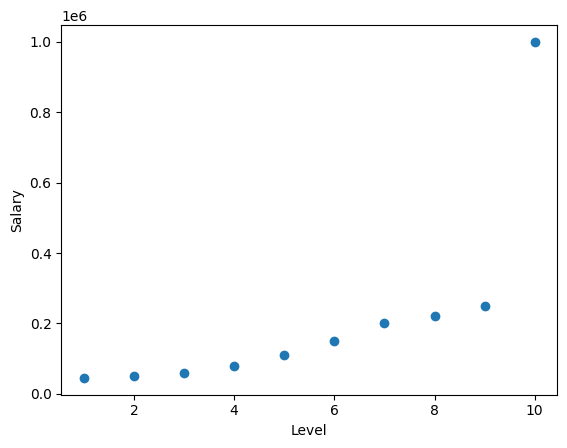

In [16]:
plt.scatter(df["Level "] , df["Salary"])  # we have small data but we can see it is forming curve 
plt.xlabel("Level")
plt.ylabel("Salary")
plt.show()

Checking correlation :

<Axes: xlabel='Level ', ylabel='Salary'>

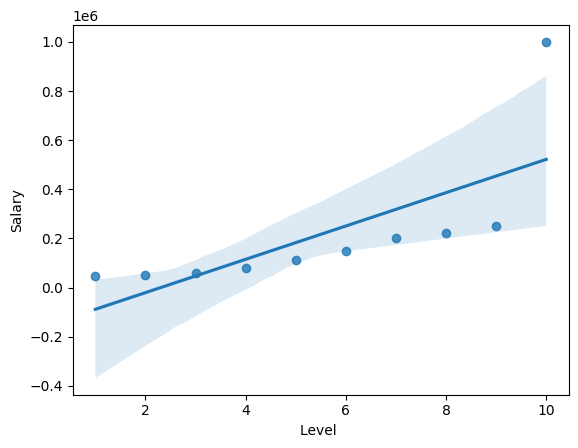

In [17]:
sns.regplot(x="Level ", y="Salary", data=df)  # this is showing the curve more clearly

distributing dataset into dependent and independent variable :

In [18]:
x = df[["Level "]]  # this is the independent variable
y = df["Salary"]  # this is the dependent variable

train_test spliting :

In [19]:
x_train , x_test, y_train ,y_test = train_test_split(x,y,test_size=0.2,random_state=10)

Converting data into POLYNOMIAL FEATURE / NATURE :


In [20]:
pf = PolynomialFeatures(degree=2) # this is the degree of the polynomial we want to fit. x^2 + x + 1

x_train_poly = pf.fit_transform(x_train)  # this will create new features for us. it will create x^2 and x and 1
x_test_poly = pf.transform(x_test)


Polynomial Regression Apply :


In [21]:
lr = LinearRegression()
lr.fit(x_train_poly,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Accuracy score :

In [22]:
lr.score(x_test_poly,y_test) # my accuracy score is low beacuse of small data but it is better than linear regression model

-7.430823393170339

Prediction of data :

for prediction we will pass the data(data should be transformed in polynomial feature /nature)

In [23]:
pred1 = lr.predict(pf.transform([[6.5]]))  # this will predict the salary for level 6.5
print(pred1)

[181811.03920926]


/home/ayush-paliwal/PythonEnvironments/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


In [24]:
# or we can do prediction this way also

test = pf.transform([[6.5]])
pred2 = lr.predict(test)
print(pred2)

[181811.03920926]


/home/ayush-paliwal/PythonEnvironments/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


Checking Prediction Line :

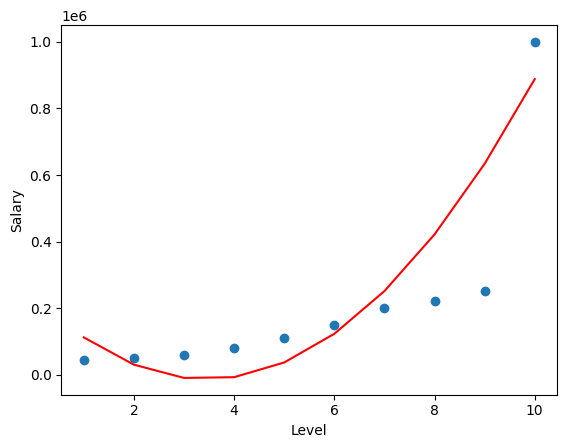

In [25]:
plt.scatter(df["Level "] , df["Salary"])  
plt.plot(df["Level "], lr.predict(pf.transform(df[["Level "]])), color="red")  # this will plot the curve of the polynomial regression model
plt.xlabel("Level")
plt.ylabel("Salary")
plt.show()